<a href="https://colab.research.google.com/github/Rohanrathod7/my-ml-labs/blob/main/21_Intermediate_Deep_Learning_with_PyTorch/01_Training_Robust_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 01 Training Robust Neural Networks

### PyTorch and object-oriented programming

**PyTorch Dataset**  
Time to refresh your PyTorch Datasets knowledge!

Before model training can commence, you need to load the data and pass it to the model in the right format. In PyTorch, this is handled by Datasets and DataLoaders. Let's start with building a PyTorch Dataset for our water potability data.

In this exercise, you will define a class called WaterDataset to load the data from a CSV file. To do this, you will need to implement the three methods which PyTorch expects a Dataset to have:

      .__init__() to load the data,
      .__len__() to return data size,
      .__getitem()__ to extract features and label for a single sample.
The following imports that you need have already been done for you:

    import pandas as pd
    from torch.utils.data import Dataset

In [25]:
csv_path = "https://github.com/Rohanrathod7/my-ml-labs/blob/main/21_Intermediate_Deep_Learning_with_PyTorch/Dataset/water_potability/water_potability/water_train.csv"

import pandas as pd
from torch.utils.data import Dataset

class WaterDataset(Dataset):
    def __init__(self, csv_path):
        super().__init__()
        # Load data to pandas DataFrame
        df = pd.read_csv(csv_path)
        # Convert data to a NumPy array and assign to self.data
        self.data = df.to_numpy()

    # Implement __len__ to return the number of data samples
    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        features = self.data[idx, :-1]
        # Assign last data column to label
        label = self.data[idx, -1]
        return features, label

***PyTorch DataLoader***  
Good job defining the Dataset class! The WaterDataset you just created is now available for you to use.

The next step in preparing the training data is to set up a DataLoader. A PyTorch DataLoader can be created from a Dataset to load data, split it into batches, and perform transformations on the data if desired. Then, it yields a data sample ready for training.

In this exercise, you will build a DataLoader based on the WaterDataset. The DataLoader class you will need has already been imported for you from torch.utils.data. Let's get to it!

In [26]:
class WaterDataset(Dataset):
    def __init__(self, csv_path):
        super().__init__()
        # Load data to pandas DataFrame
        df = pd.read_csv(csv_path)
        # Convert data to a NumPy array and assign to self.data
        self.data = df.to_numpy()

    # Implement __len__ to return the number of data samples
    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        features = self.data[idx, :-1]
        # Assign last data column to label
        label = self.data[idx, -1]
        return features, label

**PyTorch Model**  
You will use the OOP approach to define the model architecture. Recall that this requires setting up a model class and defining two methods inside it:

- .__init__(), in which you define the layers you want to use;

- forward(), in which you define what happens to the model inputs once itreceives them; this is where you pass inputs through pre-defined layers.

Let's build a model with three linear layers and ReLU activations. After the last linear layer, you need a sigmoid activation instead, which is well-suited for binary classification tasks like our water potability prediction problem. Here's the model defined using nn.Sequential(), which you may be more familiar with:

    net = nn.Sequential(
      nn.Linear(9, 16),
      nn.ReLU(),
      nn.Linear(16, 8),
      nn.ReLU(),
      nn.Linear(8, 1),
      nn.Sigmoid(),
    )
Let's rewrite this model as a class!

In [27]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # Define the three linear layers
        self.fc1 = nn.Linear(9, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)

    def forward(self, x):
        # Pass x through linear layers adding activations
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        x = nn.functional.sigmoid(self.fc3(x))
        return x

### Optimizers, training, and evaluation

**Training loop**  
Time to refresh your knowledge on training loops! Let's train a classifier to predict water potability. You will use the model called net, which you built in the previous lesson.

The training loop code has already been written but, unfortunately, all the code lines got mixed up! Can you sort them to recover the proper order of operations performed during training?

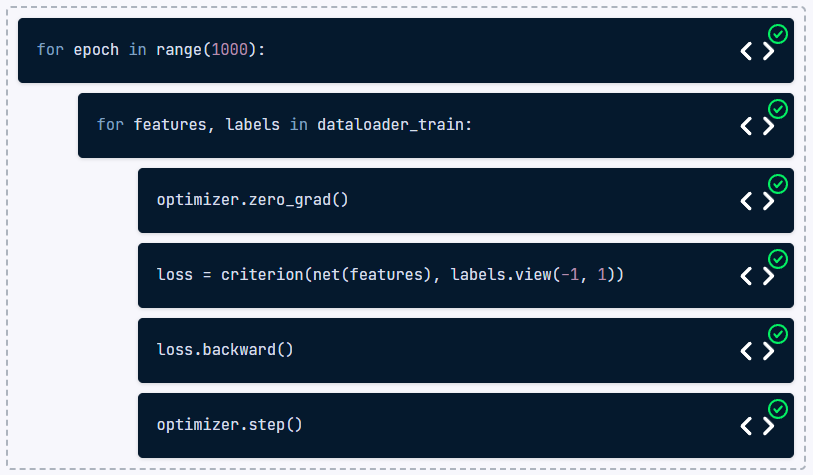

**Optimizers**  
It's time to explore the different optimizers that you can use for training your model.

A custom function called train_model(optimizer, net, num_epochs) has been defined for you. It takes the optimizer, the model, and the number of epochs as inputs, runs the training loops, and prints the training loss at the end.

Let's use train_model() to run a few short trainings with different optimizers and compare the results!

In [32]:
import torch
import torch.nn as nn

def train_model(optimizer, net, num_epochs, dataloader=None):
    """
    Trains the given model for a specified number of epochs using the provided optimizer and dataloader.

    Args:
        optimizer: The optimizer to use for training.
        net: The neural network model to train.
        num_epochs: The number of epochs to train for.
        dataloader: The DataLoader to use for fetching data batches.
    """
    criterion = nn.BCELoss() # Binary Cross Entropy Loss for binary classification

    if dataloader is None:
        print("Warning: No dataloader provided. Training will not be possible.")
        return

    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, labels in dataloader:
            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = net(inputs.float())
            loss = criterion(outputs, labels.float().unsqueeze(1))

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(dataloader)}")

In [29]:
import torch.optim as optim

net = Net()

# Define the SGD optimizer
optimizer = optim.SGD(net.parameters(), lr=0.001)

train_model(
    optimizer=optimizer,
    net=net,
    num_epochs=10,
)

In [30]:
import torch.optim as optim

net = Net()

# Define the RMSprop optimizer
optimizer = optim.RMSprop(net.parameters(), lr=0.001)

train_model(
    optimizer=optimizer,
    net=net,
    num_epochs=10,
)

In [ ]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np # Import numpy

net = Net()

# Define the Adam optimizer
optimizer = optim.Adam(net.parameters(), lr=0.001)

# Create an instance of WaterDataset
# Ensure the WaterDataset class is defined before this cell or in a previous cell.
# The __getitem__ method should return tensors.
# Assuming WaterDataset is defined elsewhere and its __getitem__ returns numpy arrays,
# we will redefine it here for clarity and to ensure tensor conversion.
# In a real notebook, you would define this class once before using it.


dataset = WaterDataset(csv_path)


# Create a DataLoader instance
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

train_model(
    optimizer=optimizer,
    net=net,
    num_epochs=10,
    dataloader = dataloader
)

# Model training has some randomness to it and each time you get slightly different results,
# but it's very likely that you saw RMSprop and Adam decreasing the loss more than a simple SGD even after just 10 training epochs

**Model evaluation**  
With the training loop sorted out, you have trained the model for 1000 epochs, and it is available to you as net. You have also set up a test_dataloader in exactly the same way as you did with train_dataloader before—just reading the data from the test rather than the train directory.

You can now evaluate the model on test data. To do this, you will need to write the evaluation loop to iterate over the batches of test data, get the model's predictions for each batch, and calculate the accuracy score for it. Let's do it!

In [ ]:
import torch
from torchmetrics import Accuracy

# Set up binary accuracy metric
acc = Accuracy(task="binary")

net.eval()
with torch.no_grad():
    for features, labels in dataloader_test:
        # Get predicted probabilities for test data batch
        outputs = net(features)
        preds = (outputs >= 0.5).float()
        acc(preds, labels.view(-1, 1))

# Compute total test accuracy
test_accuracy = acc.compute()
print(f"Test accuracy: {test_accuracy}")

### Vanishing and exploding gradients

**Initialization and activation**  
The problems of unstable (vanishing or exploding) gradients are a challenge that often arises in training deep neural networks. In this and the following exercises, you will expand the model architecture that you built for the water potability classification task to make it more immune to those problems.

As a first step, you'll improve the weights initialization by using He (Kaiming) initialization strategy. To do so, you will need to call the proper initializer from the torch.nn.init module, which has been imported for you as init. Next, you will update the activations functions from the default ReLU to the often better ELU.

In [34]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(9, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)

        # Apply He initialization
        init.kaiming_uniform_(self.fc1.weight)
        init.kaiming_uniform_(self.fc2.weight)
        init.kaiming_uniform_(self.fc3.weight,
                    nonlinearity="sigmoid")

    def forward(self, x):
        # Update ReLU activation to ELU
        x = nn.functional.elu(self.fc1(x))
        x = nn.functional.elu(self.fc2(x))
        x = nn.functional.sigmoid(self.fc3(x))
        return x

**Activations: ReLU vs. ELU**  
The choice of the activation functions used in the model (combined with the corresponding weight initialization) can have a strong impact on the training process. In particular, the proper activation can prevent the network from experiencing unstable gradients problems.

In the previous exercise, you have switched from ReLU to ELU activations. Do you remember which characteristics of the two activations justify this change?

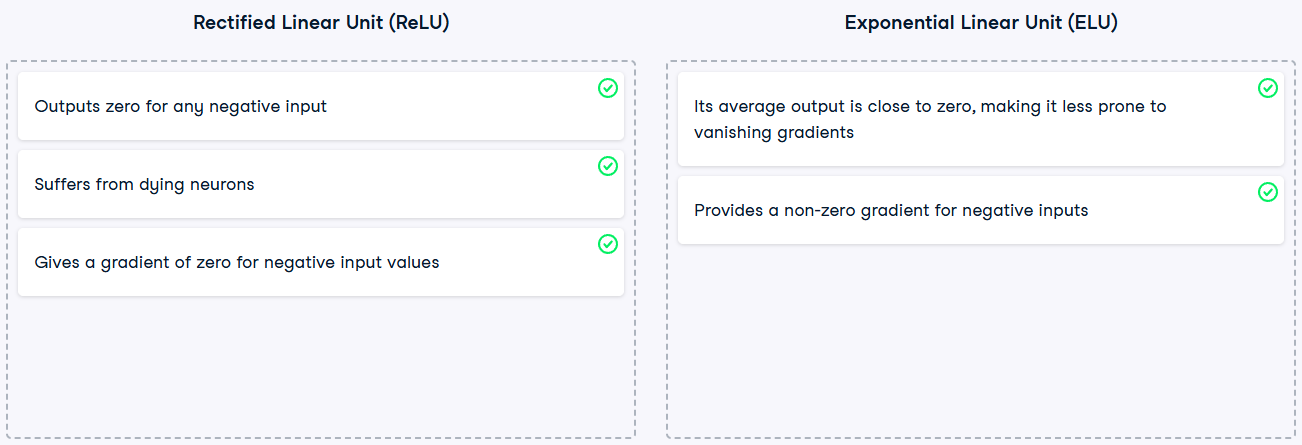

**Batch Normalization**  
As a final improvement to the model architecture, let's add the batch normalization layer after each of the two linear layers. The batch norm trick tends to accelerate training convergence and protects the model from vanishing and exploding gradients issues.

Both torch.nn and torch.nn.init have already been imported for you as nn and init, respectively. Once you implement the change in the model architecture, be ready to answer a short question on how batch normalization works!

In [36]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(9, 16)
        # Add two batch normalization layers
        self.bn1 = nn.BatchNorm1d(16)
        self.fc2 = nn.Linear(16, 8)
        self.bn2 = nn.BatchNorm1d(8)
        self.fc3 = nn.Linear(8, 1)

        init.kaiming_uniform_(self.fc1.weight)
        init.kaiming_uniform_(self.fc2.weight)
        init.kaiming_uniform_(self.fc3.weight, nonlinearity="sigmoid")

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = nn.functional.elu(x)

        # Pass x through the second set of layers
        x = self.fc2(x)
        x = self.bn2(x)
        x = nn.functional.elu(x)

        x = nn.functional.sigmoid(self.fc3(x))
        return x

# Batch normalization effectively learns the optimal input distribution for each layer it precedes.
#  learning how to optimally re-scale the next layer's inputs, batch normalization mitigates the unstable gradients problems!
#  Congratulations on finishing Chapter 1 of this course! See you in Chapter 2, where we will build convolutional
#  neural networks (CNNs)—models designed for image processing!

